In [8]:
from scipy.optimize import minimize
from scipy.optimize import LinearConstraint

import cv2
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import numpy as np
import imutils
from skimage.feature import blob_dog, blob_log
from skimage.transform import rotate

from collections import Counter


In [14]:
original_img = cv2.imread('/home/yuxin.chang/fantastx/examples/from_Thiago/yuxin_edit/ssim_tests/POSCAR_Pt_6layer_yuxin_edit_mirrrored_100slc_850x850_12nmDefocus.png', cv2.IMREAD_GRAYSCALE)
original_img = cv2.imread('/home/share/g-chan/yuxin_all/fantastx_examples/test_trailrun/calcs/1/relax/dr_probe_output/POSCAR_relaxed/defocus_images/POSCAR_relaxed_100slc_180x135_16nmDefocus.png', cv2.IMREAD_GRAYSCALE)

original_img.shape

(369, 492)

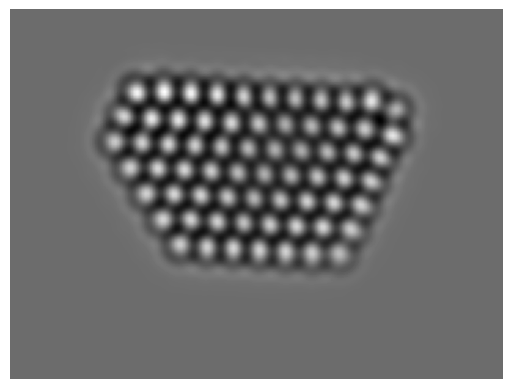

In [15]:
plt.imshow(original_img,cmap='gray')
plt.axis('off')
plt.show()

In [16]:
def get_background_color(img):
    """Find the most common pixel intensity (background color)."""
    flat_image = img.flatten()  # Flatten to 1D
    most_common = Counter(flat_image).most_common(1)[0][0]  # Get most frequent value
    return most_common

In [74]:
background_color = get_background_color(original_img)
background_color
type(background_color)

numpy.uint8

In [48]:
def translate_img(img,delta_x,delta_y):
    # if fill blank with background color:
    blank_x = np.full((img.shape[0], abs(delta_x)),background_color, dtype=img.dtype)
    # shifted_image_x = np.concatenate((img[:, delta_x:], blank_x), axis=1)
    shifted_image_x = np.concatenate((img[:, delta_x:], img[:, :delta_x]), axis=1)
    # shifted_image_xy = np.concatenate((shifted_image_x[delta_y:], shifted_image_x[:delta_y]), axis=0)
    return shifted_image_x


In [75]:
def translate_img(img,delta_x,delta_y):
    M = np.float32([[1, 0, delta_x], [0, 1, delta_y]])

    # Perform the translation along both axes
    translated_img = cv2.warpAffine(image, M, (image.shape[1], image.shape[0]), borderValue=background_color)
    return translated_img

In [80]:
translated_img = translate_img(original_img,200,0)
translated_img.shape

(369, 492)

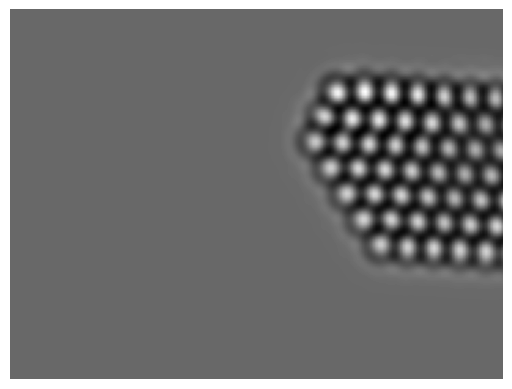

In [81]:
plt.imshow(translated_img,cmap='gray')
plt.axis('off')
plt.show()